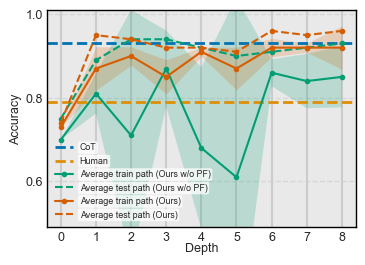

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
 
depth = np.arange(9)

base_train_mean = [0.70, 0.81, 0.71, 0.87, 0.68, 0.61, 0.86, 0.84, 0.85]
base_train_std  = [0.000,0.048,0.300,0.091,0.193,0.429,0.032,0.065,0.073]

base_test_mean = [0.75, 0.89, 0.94, 0.94, 0.92, 0.90, 0.91, 0.92, 0.93]
base_test_std  = [0.000]*9

ours_train_mean = [0.73, 0.87, 0.90, 0.85, 0.91, 0.87, 0.92, 0.92, 0.92]
ours_train_std  = [0.000,0.052,0.022,0.041,0.011,0.051,0.022,0.011,0.052]

ours_test_mean = [0.74, 0.95, 0.94, 0.92, 0.92, 0.91, 0.96, 0.95, 0.96]
ours_test_std  = [0.000]*9
 
sns.set(style="whitegrid", context="talk", palette="colorblind")

plt.figure(figsize=(4.0,3.0))
ax = plt.gca()
ax.set_facecolor("#e9e9e9") 
# def plot_with_shade(x, mean, std, label, color, marker, dash=False):
#     if dash:
#         plt.plot(x, mean, label=label, color=color, marker=marker, linewidth=1.5, markersize=4, linestyle='--')
#     else:
#         plt.plot(x, mean, label=label, color=color, marker=marker, linewidth=1.5, markersize=4)
#     plt.fill_between(
#         x,
#         np.array(mean) - np.array(std),
#         np.array(mean) + np.array(std),
#         color=color, alpha=0.2, linewidth=0, edgecolor=None
#     ) 
#     # for xi, yi in zip(x, mean):
#     #     plt.text(xi, yi + 0.010, f"{yi:.2f}", ha='center', va='bottom', fontsize=9, color='k')
  
palette = sns.color_palette("Set3", 6)

palette = sns.color_palette("colorblind", 4)
plt.axhline(y=0.93, color=palette[0], linestyle='--', linewidth=2, label='CoT')
# plt.text(0, 0.93 + 0.015, f"{0.93:.2f}", ha='center', va='bottom', fontsize=9, color="k")
plt.axhline(y=0.79, color=palette[1], linestyle='--', linewidth=2, label='Human')
# plt.text(0, 0.79 + 0.015, f"{0.79:.2f}", ha='center', va='bottom', fontsize=9, color="k")

# plot_with_shade(depth, base_train_mean, base_train_std, "Average train path (Ours w/o PF)", palette[2], "o")
# plot_with_shade(depth, base_test_mean, base_test_std, "Average test path (Ours w/o PF)", palette[2], "o", dash=True)
# plot_with_shade(depth, ours_train_mean, ours_train_std, "Average train path (Ours)", palette[3], "o")
# plot_with_shade(depth, ours_test_mean, ours_test_std, "Average test path (Ours)", palette[3], "o", dash= True)

plt.ylim(0.49, 1.01)
plt.xticks(depth)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel("Depth", fontsize=9)
plt.ylabel("Accuracy", fontsize=9) 


for spine in ax.spines.values():
    spine.set_edgecolor("#000000")
    spine.set_linewidth(1.0)

for label in ax.get_yticklabels():
    label.set_x(label.get_position()[0] + 0.045)

    # Move ylabel slightly to the right
    ax.yaxis.set_label_coords(-0.08, 0.5)

for label in ax.get_xticklabels():
    label.set_y(label.get_position()[1] + 0.06)
    ax.xaxis.set_label_coords(0.5, -0.07)
ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.6) 
    
plt.legend(title="", loc="lower left", fontsize=7, frameon=False)
# 점선 라벨(테스트 라인)은 marker 없이 그려서, 실선+marker와 구분되게 만듭니다.
def plot_with_shade(x, mean, std, label, color, marker=None, dash=False):
    if dash:
        plt.plot(x, mean, label=label, color=color, linewidth=1.5, linestyle='--')
    else:
        plt.plot(x, mean, label=label, color=color, marker=marker, linewidth=1.5, markersize=3)
    plt.fill_between(
        x,
        np.array(mean) - np.array(std),
        np.array(mean) + np.array(std),
        color=color, alpha=0.2, linewidth=0, edgecolor=None
    )

# 아래에서 테스트 라인(dash=True)은 marker=None으로 호출
plot_with_shade(depth, base_train_mean, base_train_std, "Average train path (Ours w/o PF)", palette[2], "o")
plot_with_shade(depth, base_test_mean, base_test_std, "Average test path (Ours w/o PF)", palette[2], None, dash=True)
plt.plot(depth, base_test_mean, linestyle='None', marker='o', color=palette[2], markersize=3)
plot_with_shade(depth, ours_train_mean, ours_train_std, "Average train path (Ours)", palette[3], "o")
plot_with_shade(depth, ours_test_mean, ours_test_std, "Average test path (Ours)", palette[3], None, dash=True)
plt.plot(depth, ours_test_mean, linestyle='None', marker='o', color=palette[3], markersize=3)

leg = ax.legend(
    ncols=1, frameon=False,
    fontsize=6.4, 
)

# 점선(dash=True)으로 그린 테스트 라인 위에 o 마커만 따로 표시

for text in leg.get_texts():
    text.set_bbox(dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))
plt.tight_layout()
plt.savefig("reward_by_depth.pdf", dpi=300)
plt.show()


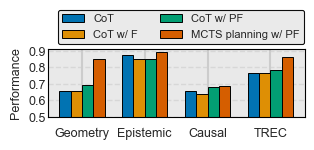

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tasks = ["Geometry",   "Epistemic", "Causal", "TREC"]
methods = ["CoT", "CoT w/ F", "CoT w/ PF", "MCTS planning w/ PF"]
data = {
    "Geometry":          [0.6600, 0.6550, 0.6950, 0.8500],
    "Epistemic":        [0.8720, 0.8500, 0.8480, 0.8920],
    "Causal":  [0.6600, 0.6400, 0.6800, 0.6900],
    "TREC":        [0.7640, 0.7660, 0.7820, 0.8600],
}



palette = sns.color_palette("colorblind", 5)
x = np.arange(len(tasks))
width = 0.18

fig, ax = plt.subplots() 
fig.set_size_inches(3.5, 1.8)
sns.set(style="whitegrid", context="talk", palette="colorblind")


hatches = ["", "//", "xx", "oo"]


bars_by_method = []
for i, method in enumerate(methods):
    vals = [data[t][i] for t in tasks]
    # Bars centered around each tick: offset = (i - (k-1)/2) * width
    offset = (i - (len(methods) - 1) / 2.0) * width
    bars = ax.bar(
        x + offset, vals, width=width,
        label=method,
        edgecolor="black", linewidth=0.7,
        color=palette[i % len(palette)], 
    )
    # for b in bars:
    #     b.set_hatch(hatches[i])
    bars_by_method.append(bars)


ax.set_ylabel("Performance", fontsize=9)
# ax.set_xlabel("Task", fontsize=10)
ax.set_xticks(x, tasks, fontsize=9) 

ax.set_ylim(0.5, 0.91)
ax.set_yticks(np.arange(0.5, 0.91, 0.1))
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.6) 
# ax.grid(axis="x", linestyle="-", linewidth=0.5, alpha=0.6) 

ax.set_facecolor("#e9e9e9") 
for spine in ax.spines.values():
    spine.set_edgecolor("#000000")
    spine.set_linewidth(1.2)
    spine.set_linewidth(0.8)

leg = ax.legend(
    ncols=2, frameon=True, fancybox=True,
    bbox_to_anchor=(1.008, 1.04), loc="lower right",
    borderaxespad=0.2,
    fontsize=8
)
leg.get_frame().set_facecolor("#e9e9e9")
leg.get_frame().set_edgecolor("#000000")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0.8)

def annotate_bars(bar_container, fmt="{:.2f}", dy=0.005):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2, h + dy,
            fmt.format(h),
            ha="center", va="bottom", fontsize=5.5
        )


# annotate_bars(bars_by_method[0], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[1], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[2], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[3], fmt="{:.2f}")  # Ours 
# ax.set_xlabel("Task", fontsize=10)
for tick in ax.get_xticklabels():
    tick.set_y(0.1)

    # Move ytick labels slightly to the right
    for label in ax.get_yticklabels():
        label.set_x(label.get_position()[0] + 0.015)

    # Move ylabel slightly to the right
    ax.yaxis.set_label_coords(-0.1, 0.5) 



plt.tight_layout()
plt.savefig("motivation_example.pdf", bbox_inches="tight", dpi=300)
plt.show()


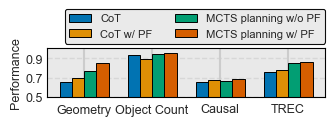

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tasks = ["Geometry", "Object Count", "Causal", "TREC"]
methods = ["CoT", "CoT w/ PF", "MCTS planning w/o PF", "MCTS planning w/ PF"] # CoT = CoT w/ F
data = {
    "Geometry":          [0.6600, 0.6950, 0.7750, 0.8500],
    # "Epistemic":         [0.8720, 0.8480, 0.8920, 0.8920],
    "Object Count"  :    [0.9360, 0.8940, 0.9480 ,0.9620],
    "Causal":            [0.6600, 0.6800, 0.6700, 0.6900],
    "TREC":              [0.7640, 0.7820, 0.8540, 0.8600],
}



palette = sns.color_palette("colorblind", 4)
x = np.arange(len(tasks))
width = 0.18

fig, ax = plt.subplots() 
fig.set_size_inches(3.7, 1.6)
sns.set(style="whitegrid", context="talk", palette="colorblind")


hatches = ["", "//", "xx", "oo"]


bars_by_method = []
for i, method in enumerate(methods):
    vals = [data[t][i] for t in tasks]
    # Bars centered around each tick: offset = (i - (k-1)/2) * width
    offset = (i - (len(methods) - 1) / 2.0) * width
    bars = ax.bar(
        x + offset, vals, width=width,
        label=method,
        edgecolor="black", linewidth=0.7,
        color=palette[i % len(palette)], 
    )
    # for b in bars:
    #     b.set_hatch(hatches[i])
    bars_by_method.append(bars)


ax.set_ylabel("Performance", fontsize=9)
# ax.set_xlabel("Task", fontsize=10)
ax.set_xticks(x, tasks, fontsize=9) 

ax.set_ylim(0.5, 1.01)
ax.set_yticks(np.arange(0.5, 1.01, 0.2))
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.6) 
# ax.grid(axis="x", linestyle="-", linewidth=0.5, alpha=0.6) 

ax.set_facecolor("#e9e9e9") 
for spine in ax.spines.values():
    spine.set_edgecolor("#000000")
    spine.set_linewidth(1.2)
    spine.set_linewidth(0.8)

leg = ax.legend(
    ncols=2, frameon=True, fancybox=True,
    bbox_to_anchor=(1.008, 1.04), loc="lower right",
    borderaxespad=0.2,
    fontsize=8
)
leg.get_frame().set_facecolor("#e9e9e9")
leg.get_frame().set_edgecolor("#000000")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0.8)

def annotate_bars(bar_container, fmt="{:.2f}", dy=0.005):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2, h + dy,
            fmt.format(h),
            ha="center", va="bottom", fontsize=5.5
        )


# annotate_bars(bars_by_method[0], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[1], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[2], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[3], fmt="{:.2f}")  # Ours 
# ax.set_xlabel("Task", fontsize=10)     

# for label in ax.get_yticklabels():
#     label.set_x(label.get_position()[0] + 0.045)

for tick in ax.get_xticklabels():
    tick.set_y(0.1)

    # Move ytick labels slightly to the right
    for label in ax.get_yticklabels():
        label.set_x(label.get_position()[0] + 0.012)

    # Move ylabel slightly to the right
    ax.yaxis.set_label_coords(-0.09, 0.5)

plt.rcParams['xtick.bottom'] = True
ax.tick_params(axis='x', which='major', width=1, length=3, labelsize=9)
for label in ax.get_xticklabels():
    label.set_y(label.get_position()[1] -0.05)
    # ax.xaxis.set_label_coords(0.5, -0.2)

plt.tight_layout()
plt.savefig("motivation_example3.pdf", bbox_inches="tight")
plt.show()


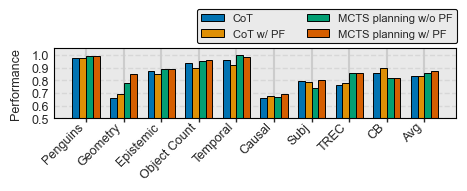

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tasks = ["Penguins", "Geometry", "Epistemic", "Object Count", "Temporal", "Causal", "Subj", "TREC", "CB", "Avg"]
methods = ["CoT", "CoT w/ PF", "MCTS planning w/o PF", "MCTS planning w/ PF"]
data = {
    "Penguins"      : [0.9747, 0.9747, 0.9873, 0.9873],
    "Geometry"      : [0.6600, 0.6950, 0.7750 ,0.8500],
    "Epistemic"     : [0.8720, 0.8480, 0.8920 ,0.8920],
    "Object Count"  : [0.9360, 0.8940, 0.9480 ,0.9620],
    "Temporal"      : [0.9620, 0.9220, 0.9960 ,0.9860],
    "Causal"        : [0.6600, 0.6800, 0.6700 ,0.6900],
    "Subj"          : [0.7960, 0.7850, 0.7390 ,0.8000],
    "TREC"          : [0.7640, 0.7820, 0.8540 ,0.8600],
    "CB"            : [0.8571, 0.8929, 0.8214 ,0.8214],
    "Avg"           : [0.8313, 0.8304, 0.8536 ,0.8721]

}



palette = sns.color_palette("colorblind", 4)
x = np.arange(len(tasks))
width = 0.18

fig, ax = plt.subplots() 
fig.set_size_inches(5, 2.2)
sns.set(style="whitegrid", context="talk", palette="colorblind")


hatches = ["", "//", "xx", "oo"]


bars_by_method = []
for i, method in enumerate(methods):
    vals = [data[t][i] for t in tasks]
    # Bars centered around each tick: offset = (i - (k-1)/2) * width
    offset = (i - (len(methods) - 1) / 2.0) * width
    bars = ax.bar(
        x + offset, vals, width=width,
        label=method,
        edgecolor="black", linewidth=0.7,
        color=palette[i % len(palette)], 
    )
    # for b in bars:
    #     b.set_hatch(hatches[i])
    bars_by_method.append(bars)


ax.set_ylabel("Performance", fontsize=9)
# ax.set_xlabel("Task", fontsize=10)
ax.set_xticks(x, tasks, fontsize=9) 

ax.set_ylim(0.5, 1.05)
ax.set_yticks(np.arange(0.5, 1.05, 0.1))
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.6) 
# ax.grid(axis="x", linestyle="-", linewidth=0.5, alpha=0.6) 

ax.set_facecolor("#e9e9e9") 
for spine in ax.spines.values():
    spine.set_edgecolor("#000000")
    spine.set_linewidth(1.2)
    spine.set_linewidth(0.8)

leg = ax.legend(
    ncols=2, frameon=True, fancybox=True,
    bbox_to_anchor=(1.008, 1.04), loc="lower right",
    borderaxespad=0.2,
    fontsize=8
)
leg.get_frame().set_facecolor("#e9e9e9")
leg.get_frame().set_edgecolor("#000000")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0.8)

def annotate_bars(bar_container, fmt="{:.2f}", dy=0.005):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2, h + dy,
            fmt.format(h),
            ha="center", va="bottom", fontsize=5.5
        )


# annotate_bars(bars_by_method[0], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[1], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[2], fmt="{:.2f}")  # CoT + Generalized FB
# annotate_bars(bars_by_method[3], fmt="{:.2f}")  # Ours 
# ax.set_xlabel("Task", fontsize=10)
for tick in ax.get_xticklabels():
    tick.set_y(0.1)

    # Move ytick labels slightly to the right
    for label in ax.get_yticklabels():
        label.set_x(label.get_position()[0] + 0.003)

    # Move ylabel slightly to the right
    ax.yaxis.set_label_coords(-0.08, 0.5)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", visible=True)
ax.spines['bottom'].set_visible(True)

plt.rcParams['xtick.bottom'] = True
ax.tick_params(axis='x', which='major', width=1, length=3, labelsize=9, rotation=45)
# plt.setp( ax.get_xticklabels(), visible=True)
# plt.tick_params(axis='x', direction='out', length=10, pad=15, labelsize=1, width=2, color='r')
# ax.xaxis.set_label_coords(0.5, -0.22)

plt.tight_layout()
plt.savefig("motivation_example2.pdf", bbox_inches="tight")
plt.show()
